# Download Data

In [5]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games_Injuries_Travel_Bio.parquet')
df = df.drop(columns=['days_to_next_injury', 'injury_within_7d',
                      'injury_within_30d','Name', 'coachId'])
df.head()

,personId,gameId,gameDateTimeEst_player,playerteamName,gameType_player,win_player,home_player,numMinutes_player,points_player,assists_player,...,direction_ew,tz_shift_hrs,rest_days,flight_minutes,height,weight,birthdate,experience,bmi,age
0,255.0,21000521,2011-01-05 22:30:00,Suns,Regular Season,0.0,1.0,34.0,10.0,2.0,...,East,1.0,2.0,69.3,80.0,225.0,1972-10-05,18,24.714844,38.250513
1,255.0,21000533,2011-01-07 22:30:00,Suns,Regular Season,0.0,1.0,29.0,10.0,2.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.255989
2,255.0,21000584,2011-01-14 22:30:00,Suns,Regular Season,1.0,1.0,36.0,21.0,3.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.275154
3,255.0,21000598,2011-01-17 13:00:00,Suns,Regular Season,1.0,0.0,37.0,25.0,2.0,...,East,2.0,2.0,234.0,80.0,225.0,1972-10-05,18,24.714844,38.283368
4,255.0,21000613,2011-01-19 19:00:00,Suns,Regular Season,1.0,0.0,40.0,27.0,2.0,...,West,0.0,1.0,44.1,80.0,225.0,1972-10-05,18,24.714844,38.288843


In [6]:
seasons = sorted(df['season_x'].unique())

test_season = seasons[-1]
val_season = seasons[-2]
train_seasons = seasons[:-2]

test_df = df[df['season_x'] == test_season]
val_df = df[df['season_x'] == val_season]
train_df = df[df['season_x'].isin(train_seasons)]

In [7]:
print(len(test_df), len(val_df), len(train_df))
print(test_df['injury_within_14d'].mean())

22937 23295 286926
0.19819505602301957


In [8]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
import numpy as np

def univariate_auc(feature, X, y, groups, n_splits=5):
  X_feat = X[[feature]].values
  gkf = GroupKFold(n_splits=n_splits)
  aucs = []

  for train_idx, test_idx in gkf.split(X_feat, y, groups):
    X_train, X_test = X_feat[train_idx], X_feat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y_test, y_pred))

  return np.mean(aucs) if len(aucs) > 0 else np.nan

In [9]:
target = 'injury_within_14d'
group_col = 'personId'

X = train_df.drop(columns=[target])
y = train_df[target].values
groups = train_df[group_col].values

results = []

# Not using stats from the same game due to potential leakage
drop_cols = ['season_x', 'numMinutes_player', 'points_player',
             'assists_player', 'blocks_player', 'steals_player',
             'fieldGoalsAttempted_player', 'fieldGoalsMade_player',
             'fieldGoalsPercentage_player', 'threePointersAttempted_player',
             'threePointersMade_player', 'threePointersPercentage_player',
             'freeThrowsAttempted_player', 'freeThrowsMade_player',
             'freeThrowsPercentage_player', 'reboundsDefense_player',
             'reboundsOffensive_player', 'reboundsTotal_player',
             'foulsPersonal_player', 'turnovers_player', 'plusMinusPoints_player',
             'playerteamId_player', 'comment', 'points_per36', 'assists_per36',
             'blocks_per36', 'steals_per36', 'fieldGoalsAttempted_per36',
             'fieldGoalsMade_per36', 'threePointersAttempted_per36',
             'threePointersMade_per36', 'freeThrowsAttempted_per36',
             'freeThrowsMade_per36', 'reboundsDefensive_per36',
             'reboundsOffensive_per36', 'reboundsTotal_per36',
             'foulsPersonal_per36', 'turnovers_per36', 'plusMinusPoints_per36',
             'playerteamId_team', 'points_team', 'assists_team',
             'blocks_team', 'steals_team', 'fieldGoalsAttempted_team',
             'fieldGoalsMade_team', 'fieldGoalsPercentage_team',
             'threePointersAttempted_team', 'threePointersMade_team',
             'threePointersPercentage_team', 'freeThrowsAttempted_team',
             'freeThrowsMade_team', 'freeThrowsPercentage_team',
             'reboundsDefensive_team', 'reboundsOffensive_team',
             'reboundsTotal_team', 'foulsPersonal_team',
             'turnovers_team', 'plusMinusPoints_team', 'numMinutes_team',
             'benchPoints', 'pointsFastBreak', 'pointsFromTurnovers',
             'pointsInThePaint', 'pointsSecondChance', 'reboundsTeam',
             'turnoversTeam', 'pointDifferential', 'pointsPercent',
             'assistsPercent', 'stealsPercent', 'fieldGoalsAttemptedPercent',
             'fieldGoalsMadePercent', 'freeThrowsAttemptedPercent',
             'freeThrowsMadePercent', 'reboundsDefensivePercent',
             'reboundsOffensivePercent', 'reboundsTotalPercent',
             'foulsPersonalPercent', 'turnoversPercent', 'fgRelativePercent',
             '3pRelativePercent', 'ftRelativePercent', '3PA_rate',
             'trueShooting', 'eFG', 'FTA_rate', 'USG', 'personId', 'gameId', 'reboundsDefensive_player']

features = X.select_dtypes(include=[np.number]).columns
features = [f for f in features if f not in drop_cols]

for f in features:
  auc = univariate_auc(f, X, y, groups)
  results.append((f, auc))
  print(f'{f}: {auc}')

results.sort(key=lambda x: x[1], reverse=True)
results_df = pd.DataFrame(results, columns=['feature', 'auc'])
results_df.head()

win_player: 0.5113716509331458
home_player: 0.5006088702470142
winPercent_team: 0.5447146285877099
positionless_index: 0.5387744240172057
rolling_3g_minutes: 0.59630565735867
rolling_3g_points: 0.6143202833052237
rolling_3g_assists: 0.5876513537196837
rolling_3g_rebounds: 0.5660372085405193
rolling_3g_steals: 0.5481229539161004
rolling_3g_blocks: 0.5382476531988427
rolling_3g_turnovers: 0.566549159140554
rolling_3g_field_goals_made: 0.6088115418386109
rolling_3g_field_goals_attempted: 0.6107620986960225
rolling_3g_three_pointers_made: 0.5882393792625827
rolling_3g_three_pointers_attempted: 0.6018967816376313
rolling_3g_three_point_percent: 0.5559799629357721
rolling_3g_points_per36: 0.5951193884238833
rolling_3g_assists_per36: 0.5648718384523802
rolling_3g_blocks_per36: 0.47063223637144463
rolling_3g_steals_per36: 0.4949795792389698
rolling_3g_3p_relative_percent: 0.5506965663010721
rolling_3g_ft_relative_percent: 0.5584130554324394
rolling_3g_USG: 0.5718449657805537
rolling_7g_minutes

,feature,auc
0,rolling_7g_points,0.622145
1,rolling_7g_field_goals_made,0.617511
2,rolling_7g_field_goals_attempted,0.615589
3,rolling_3g_points,0.614320
4,rolling_3g_field_goals_attempted,0.610762


In [10]:
threshold = 0.52

selected_features = results_df[
    results_df['auc'] >= threshold
]

print(f'Total Features: {len(features)}')
print(f'Selected Features: {len(selected_features)}')


Total Features: 53
Selected Features: 37


In [11]:
from utils import prune_redundant_features

kept_features, drop_cols = prune_redundant_features(X[selected_features['feature']])
print(f'Kept Features: {len(kept_features)}')
print(f'Dropped Features: {len(drop_cols)}')

Kept Features: 34
Dropped Features: 3


In [12]:
print(kept_features)

{'rolling_7g_points', 'rolling_7g_USG', 'rolling_7g_three_point_percent', 'rolling_3g_3p_relative_percent', 'rolling_7g_turnovers', 'rolling_7g_blocks', 'rolling_3g_turnovers', 'rolling_3g_assists', 'rolling_7g_field_goals_made', 'rolling_7g_rebounds', 'rolling_7g_points_per36', 'rolling_3g_field_goals_attempted', 'rolling_7g_three_pointers_made', 'rolling_3g_points_per36', 'rolling_3g_three_pointers_made', 'winPercent_team', 'rolling_3g_rebounds', 'rolling_3g_points', 'rolling_7g_assists_per36', 'rolling_7g_field_goals_attempted', 'positionless_index', 'rolling_3g_steals', 'rolling_3g_three_point_percent', 'rolling_3g_three_pointers_attempted', 'rolling_7g_minutes', 'games_last_14d', 'rolling_7g_assists', 'rolling_3g_assists_per36', 'rolling_7g_three_pointers_attempted', 'rolling_3g_USG', 'rolling_3g_field_goals_made', 'rolling_7g_ft_relative_percent', 'rolling_7g_3p_relative_percent', 'rolling_7g_steals'}


# Model Selection
Using various non-tuned models

In [13]:
%pip install catboost
%pip install xgboost
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time

X_sel = df[list(kept_features) + ['season_x']].copy()
y_sel = df[target].values

pos = np.sum(y_sel == 1)
neg = np.sum(y_sel == 0)
scale_pos_weight = min(10, neg / pos)

models = {
    "logreg_l2": LogisticRegression(max_iter=500, penalty="l2", solver="lbfgs", n_jobs=-1,
                                    class_weight = 'balanced'),

    "logreg_l1": LogisticRegression(max_iter=500, penalty="l1", solver="saga", n_jobs=-1,
                                    class_weight = 'balanced'),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        scale_pos_weight = scale_pos_weight
    ),

    "lightgbm": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight = 'balanced'
    ),

    "catboost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        random_seed=42
    ),

    'mlp_nn': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        random_state=42
    )
}

def evaluate_model_temporal(model, X, y):
  start = time.perf_counter()
  train_mask = X['season_x'].isin(train_seasons)
  val_mask = X['season_x'] == val_season
  X_train = X.loc[train_mask].drop(columns=['season_x'])
  X_val = X.loc[val_mask].drop(columns=['season_x'])
  y_train = y[train_mask]
  y_val = y[val_mask]

  imputer = SimpleImputer(strategy='median')

  X_train = imputer.fit_transform(X_train)
  X_val = imputer.transform(X_val)

  if isinstance(model, (MLPClassifier, LogisticRegression)):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
  model.fit(X_train, y_train)
  preds = model.predict_proba(X_val)[:, 1]
  auc = roc_auc_score(y_val, preds)
  return auc, time.perf_counter() - start

In [15]:
results = []

for name, model in models.items():
    print(f"Evaluating {name}...")
    auc, elapsed = evaluate_model_temporal(
        model, X_sel, y_sel
    )

    results.append({
        "model": name,
        "auc": auc,
    })

    print(f"{name}: AUC = {auc:.4f}. Took {elapsed:.3f} seconds.")

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
results_df

Evaluating logreg_l2...
logreg_l2: AUC = 0.5827. Took 24.826 seconds.
Evaluating logreg_l1...
logreg_l1: AUC = 0.5827. Took 10.018 seconds.
Evaluating random_forest...
random_forest: AUC = 0.5862. Took 306.342 seconds.
Evaluating xgboost...
xgboost: AUC = 0.5962. Took 22.423 seconds.
Evaluating lightgbm...
[LightGBM] [Info] Number of positive: 26673, number of negative: 260253
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5705
[LightGBM] [Info] Number of data points in the train set: 286926, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\vtapi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lightgbm: AUC = 0.5985. Took 30.079 seconds.
Evaluating catboost...
catboost: AUC = 0.6066. Took 37.117 seconds.
Evaluating mlp_nn...
mlp_nn: AUC = 0.5786. Took 475.480 seconds.


c:\Users\vtapi\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,auc
5,catboost,0.606647
4,lightgbm,0.598528
3,xgboost,0.596202
2,random_forest,0.586228
1,logreg_l1,0.582665
0,logreg_l2,0.582653
6,mlp_nn,0.578568


CatBoost seems to perform the best.

In [16]:
from sklearn.metrics import average_precision_score, precision_recall_curve

X_sel = df[list(kept_features) + ['season_x']].copy()
y_sel = df[target].values

train_mask = X_sel['season_x'].isin(train_seasons)
val_mask = X_sel['season_x'] == val_season
test_mask = X_sel['season_x'] == test_season

X_train = X_sel.loc[train_mask].drop(columns=['season_x'])
X_val = X_sel.loc[val_mask].drop(columns=['season_x'])
X_test = X_sel.loc[test_mask].drop(columns=['season_x'])

y_train = y_sel[train_mask]
y_val = y_sel[val_mask]
y_test = y_sel[test_mask]

X_full_train = pd.concat([X_train, X_val], axis=0)
y_full_train = np.concatenate([y_train, y_val])

imputer = SimpleImputer(strategy='median')
imputer.set_output(transform="pandas")
X_full_train = imputer.fit_transform(X_full_train)
X_test = imputer.transform(X_test)

model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    )

model.fit(X_full_train, y_full_train)
preds = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, preds)
auc

0.6204748573556526

In [17]:
X_full_train.columns

Index(['rolling_7g_points', 'rolling_7g_USG', 'rolling_7g_three_point_percent',
       'rolling_3g_3p_relative_percent', 'rolling_7g_turnovers',
       'rolling_7g_blocks', 'rolling_3g_turnovers', 'rolling_3g_assists',
       'rolling_7g_field_goals_made', 'rolling_7g_rebounds',
       'rolling_7g_points_per36', 'rolling_3g_field_goals_attempted',
       'rolling_7g_three_pointers_made', 'rolling_3g_points_per36',
       'rolling_3g_three_pointers_made', 'winPercent_team',
       'rolling_3g_rebounds', 'rolling_3g_points', 'rolling_7g_assists_per36',
       'rolling_7g_field_goals_attempted', 'positionless_index',
       'rolling_3g_steals', 'rolling_3g_three_point_percent',
       'rolling_3g_three_pointers_attempted', 'rolling_7g_minutes',
       'games_last_14d', 'rolling_7g_assists', 'rolling_3g_assists_per36',
       'rolling_7g_three_pointers_attempted', 'rolling_3g_USG',
       'rolling_3g_field_goals_made', 'rolling_7g_ft_relative_percent',
       'rolling_7g_3p_relative_percen

In [18]:
baseline = y_test.mean()
baseline

np.float64(0.19819505602301957)

In [19]:
ap = average_precision_score(y_test, preds)
ap

0.28013443342586686

In [20]:
probs = pd.DataFrame({
    "y": y_test,
    "p": preds
}).sort_values("p", ascending=False)

for pct in [1, 5, 10, 20]:
    n = int(len(probs) * pct / 100)
    precision = probs.head(n)["y"].mean()
    print(f"Top {pct}%: {precision:.3f}")

Top 1%: 0.410
Top 5%: 0.374
Top 10%: 0.347
Top 20%: 0.300


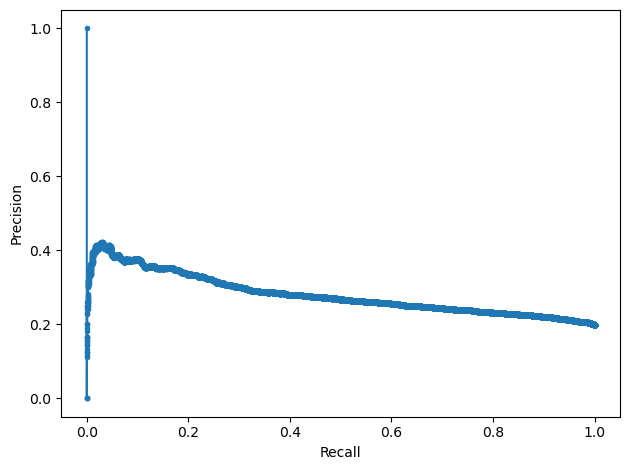

In [21]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, preds)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
fig = plt.gcf()
plt.tight_layout()

In [22]:
fig.savefig('../output/Figures/CatBoost Precision-Recall Curve.svg', format='svg',
            bbox_inches='tight')

In [23]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay

brier_score = brier_score_loss(y_test, preds)
print(f'Brier Score: {brier_score:.4f}')

Brier Score: 0.1576


In [24]:
fig.savefig('../output/Figures/CatBoost Calibration Curve.svg', format='svg',
            bbox_inches='tight')

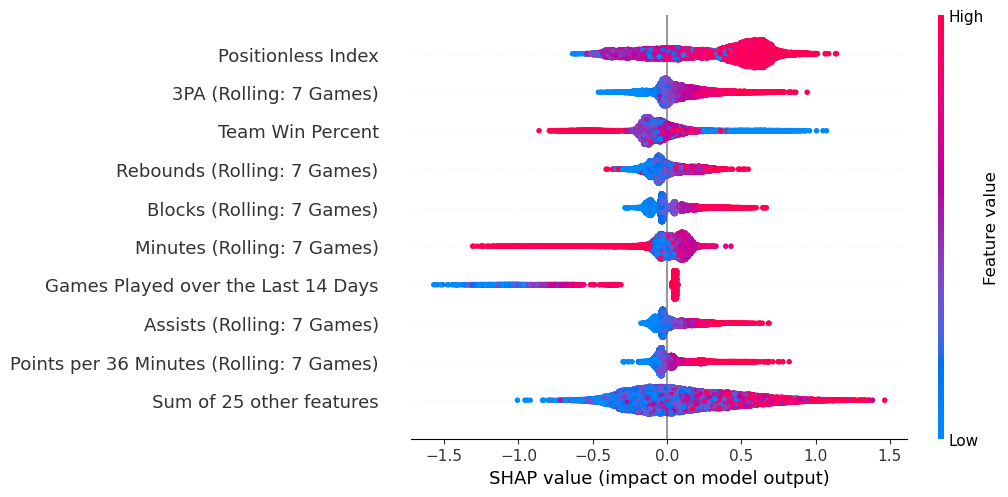

In [25]:
import shap

explainer = shap.TreeExplainer(model)

feature_renaming = {
    "rolling_7g_three_pointers_attempted": '3PA (Rolling: 7 Games)',
    'rolling_7g_USG': 'Usage Rate (Rolling: 7 Games)',
    'positionless_index': 'Positionless Index',
    'rolling_7g_points_per36': 'Points per 36 Minutes (Rolling: 7 Games)',
    'rolling_7g_rebounds': 'Rebounds (Rolling: 7 Games)',
    'winPercent_team': 'Team Win Percent',
    'rolling_7g_minutes': 'Minutes (Rolling: 7 Games)',
    'rolling_7g_blocks': 'Blocks (Rolling: 7 Games)',
    'games_last_14d': 'Games Played over the Last 14 Days',
    'rolling_7g_assists': 'Assists (Rolling: 7 Games)',
    'rolling_3g_rebounds': 'Rebounds (Rolling: 3 Games)',
    'rolling_3g_minutes': 'Minutes (Rolling: 3 Games)',
    'rolling_7g_assists_per36': 'Assists per 36 Minutes (Rolling: 7 Games)'
}

shap_values = explainer(X_test)

shap_values.feature_names = [feature_renaming[c] if c in feature_renaming else c for c in X_test.columns]

shap.plots.beeswarm(shap_values)

In [26]:
shap.plots.beeswarm(
    shap_values, show=False
)

fig = plt.gcf()

fig.savefig(
    "../output/Figures/CatBoost SHAP Summary Plot.svg",
    format="svg",
    bbox_inches="tight"
)

fig.savefig(
    "website/positionless-analytics/public/CatBoost SHAP Summary Plot.svg",
    format="svg",
    bbox_inches="tight"
)

plt.close()

<Axes: xlabel='positionless_index', ylabel='rolling_7g_three_pointers_attempted'>

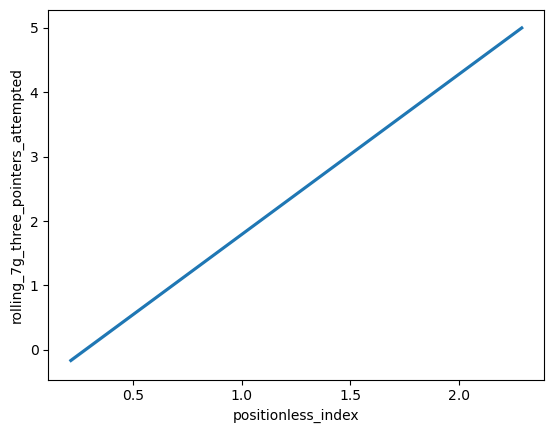

In [27]:
import seaborn as sns
sns.regplot(
    data=df,
    x="positionless_index",
    y="rolling_7g_three_pointers_attempted",
    scatter=False
)

In [28]:
df[["rolling_7g_three_pointers_attempted",
    "positionless_index"]].corr()

,rolling_7g_three_pointers_attempted,positionless_index
rolling_7g_three_pointers_attempted,1.000000,0.319492
positionless_index,0.319492,1.000000


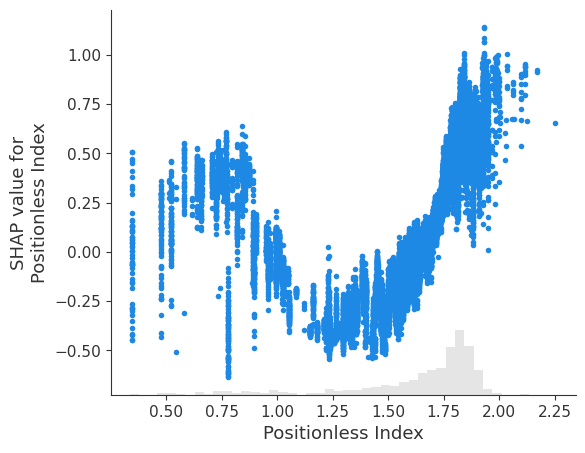

In [29]:
shap.plots.scatter(
    shap_values[:, "Positionless Index"]
)

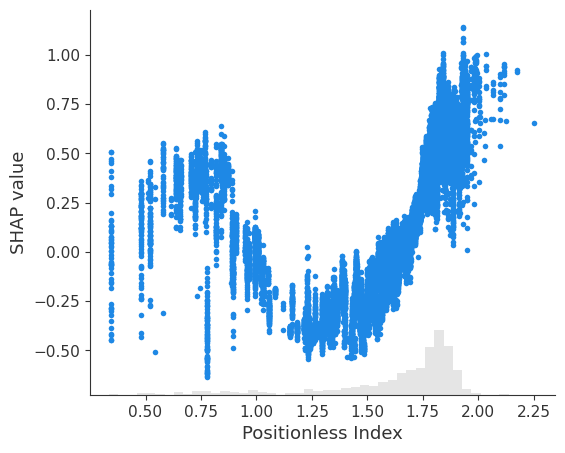

In [30]:
shap.plots.scatter(
    shap_values[:, "Positionless Index"],
    show=False
)
ax = plt.gca()

ax.set_xlabel("Positionless Index")   # x-axis label
ax.set_ylabel("SHAP value")           # y-axis label (default is SHAP value)
fig = ax.get_figure()

fig.savefig('../output/Figures/SHAP Scatter Plot for Positionless Index.svg',
            format='svg',
            bbox_inches='tight')

C:\Users\vtapi\AppData\Local\Temp\ipykernel_27368\3211816982.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pos_bin")["injury_within_14d"]


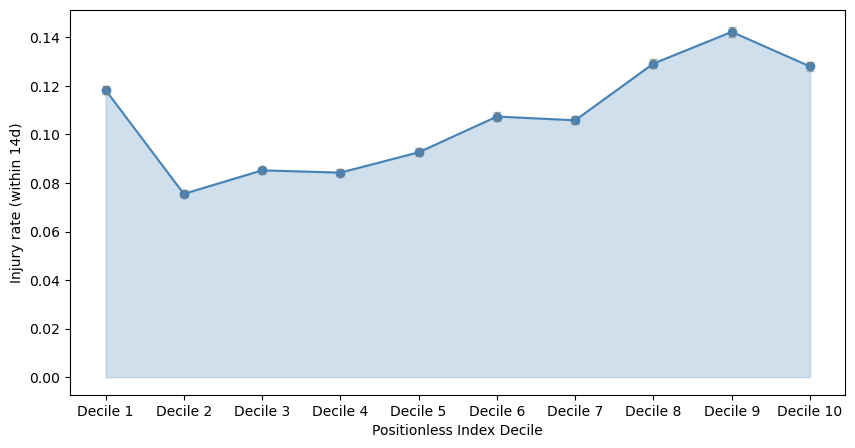

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# binning
df["pos_bin"] = pd.qcut(df["positionless_index"], 10, duplicates="drop")

# aggregate stats
plot_df = (
    df.groupby("pos_bin")["injury_within_14d"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

# decile labels
plot_df["decile"] = np.arange(1, len(plot_df) + 1)

x = plot_df["decile"]
y = plot_df["mean"]
err = plot_df["std"] / np.sqrt(plot_df['count'])

plt.figure(figsize=(10, 5))

# area under curve
plt.fill_between(x, y, color="steelblue", alpha=0.25)

# main line
plt.plot(x, y, marker="o", color="steelblue")

# error bars (±1 std)
plt.errorbar(x, y, yerr=err, fmt="none", ecolor="gray", alpha=0.6, capsize=3)

plt.xticks(x, [f"Decile {i}" for i in x], rotation=0)
plt.xlabel("Positionless Index Decile")
plt.ylabel("Injury rate (within 14d)")

fig = plt.gcf()

In [32]:
fig.savefig('../output/Figures/Positionless Index Injury Risk Decile Plot.svg',
            format='svg', bbox_inches='tight')

In [33]:
plot_df

,pos_bin,mean,std,count,decile
0,"(0.211, 1.094]",0.118339,0.323014,33328,1
1,"(1.094, 1.286]",0.075506,0.264210,33335,2
2,"(1.286, 1.432]",0.085205,0.279191,33343,3
3,"(1.432, 1.532]",0.084265,0.277789,33276,4
4,"(1.532, 1.604]",0.092625,0.289911,33317,5
5,"(1.604, 1.669]",0.107361,0.309576,33299,6
6,"(1.669, 1.732]",0.105824,0.307617,33329,7
7,"(1.732, 1.784]",0.129193,0.335419,33299,8
8,"(1.784, 1.837]",0.142231,0.349293,33333,9
9,"(1.837, 2.29]",0.127992,0.334086,33299,10


In [34]:
# Checking if this is an artifact due to minutes played

df["injuries_per_36_min"] = df["injury_within_14d"] / (df["rolling_7g_minutes"] + 1e-6) * 36
df.groupby("pos_bin")["injuries_per_36_min"].mean()

C:\Users\vtapi\AppData\Local\Temp\ipykernel_27368\534505387.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("pos_bin")["injuries_per_36_min"].mean()


pos_bin
(0.211, 1.094]    0.164764
(1.094, 1.286]    0.098025
(1.286, 1.432]    0.108029
(1.432, 1.532]    0.106921
(1.532, 1.604]    0.115811
(1.604, 1.669]    0.138913
(1.669, 1.732]    0.144297
(1.732, 1.784]    0.183421
(1.784, 1.837]    0.210356
(1.837, 2.29]     0.213344
Name: injuries_per_36_min, dtype: float64